Class Distribution:
 Reported_Health_Risk
1    0.668657
0    0.331343
Name: proportion, dtype: float64

 RESEARCH ANALYSIS (PIPELINE BUILD): Age ≤ 14
Optimal Params for KNN: {'model__n_neighbors': 5}
Optimal Params for Logistic Regression: {'model__C': 10, 'model__penalty': 'l2'}
Optimal Params for Random Forest: {'model__class_weight': None, 'model__max_depth': 3, 'model__n_estimators': 100}
Optimal Params for SVM: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

 Optimization Results :
              Model  Mean Accuracy  Mean AUC-ROC  Std Dev (ROC_AUC)  Mean F1-Score  Mean Recall
                KNN         0.8312        0.8106             0.0092         0.8767       0.9470
Logistic Regression         0.8227        0.8065             0.0211         0.8690       0.9279
      Random Forest         0.8604        0.8085             0.0154         0.9008       1.0000
        Naive Bayes         0.8054        0.7853             0.0280         0.8564       0.9158
     

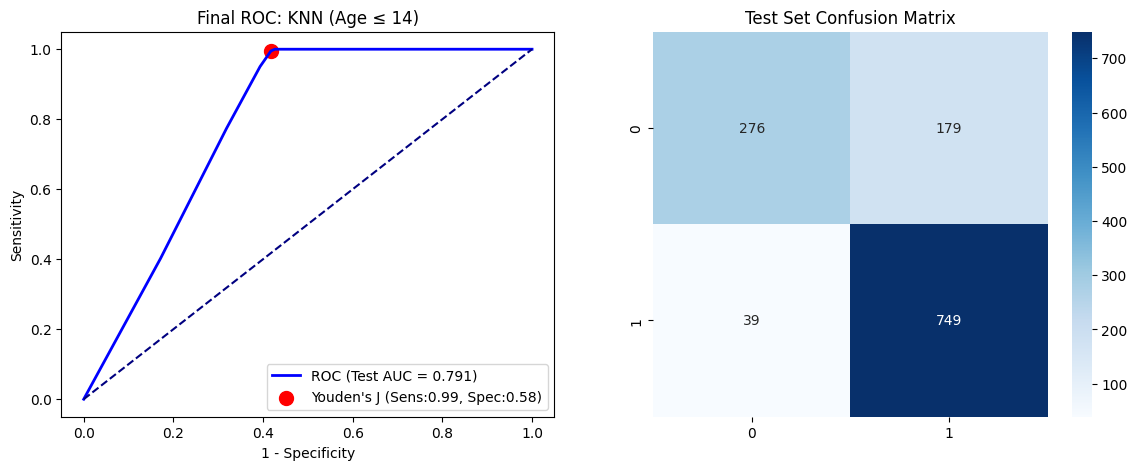

Generating SHAP Interpretations...


  0%|          | 0/500 [00:00<?, ?it/s]

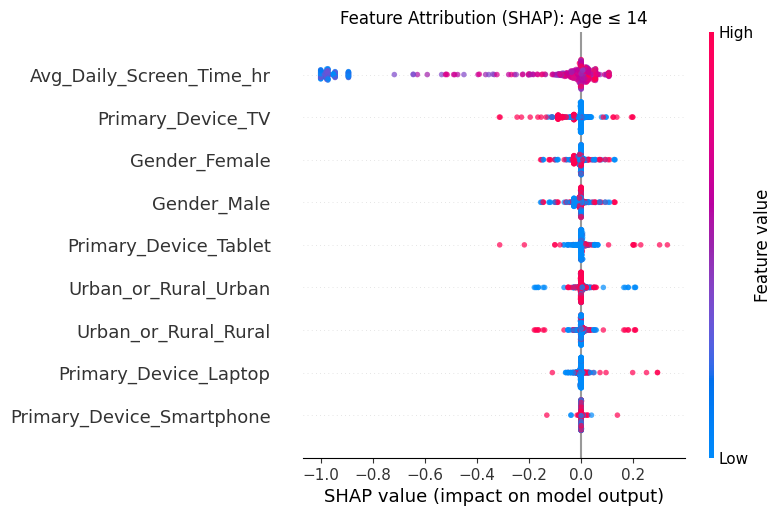


 KEY RESULTS: Age ≤ 14
  Optimized Screening Threshold: 4.78 hrs/day
  Statistical Independence (p-value): 1.98e-116
  Effect Size (Cramer's V): 0.291

 RESEARCH ANALYSIS (PIPELINE BUILD): Age 15–18
Optimal Params for KNN: {'model__n_neighbors': 11}
Optimal Params for Logistic Regression: {'model__C': 10, 'model__penalty': 'l2'}
Optimal Params for Random Forest: {'model__class_weight': None, 'model__max_depth': 5, 'model__n_estimators': 100}
Optimal Params for SVM: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

 Optimization Results :
              Model  Mean Accuracy  Mean AUC-ROC  Std Dev (ROC_AUC)  Mean F1-Score  Mean Recall
                KNN         0.8139        0.7021             0.0169         0.8853       0.9834
Logistic Regression         0.8110        0.6890             0.0211         0.8851       0.9966
      Random Forest         0.8303        0.6951             0.0111         0.8957       0.9976
        Naive Bayes         0.8121        0.6820     

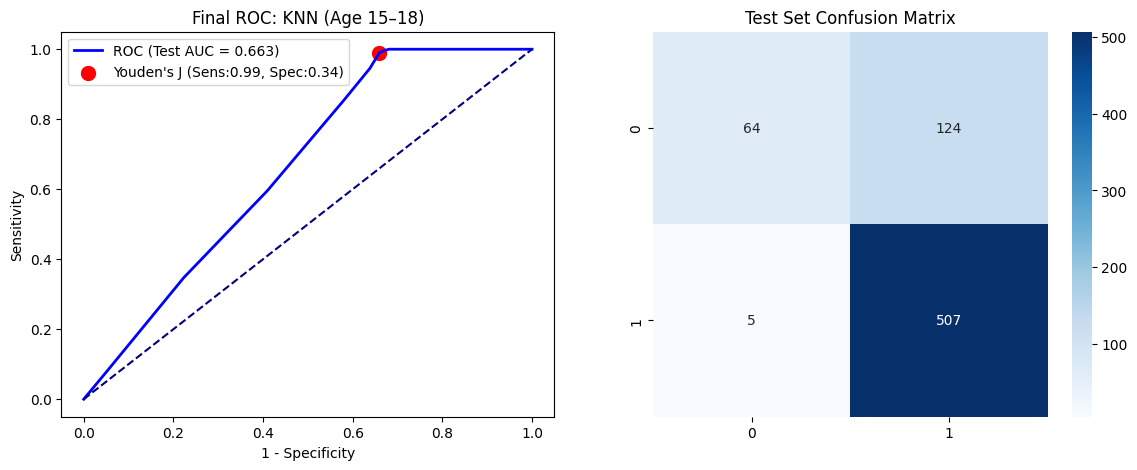

Generating SHAP Interpretations...


  0%|          | 0/500 [00:00<?, ?it/s]

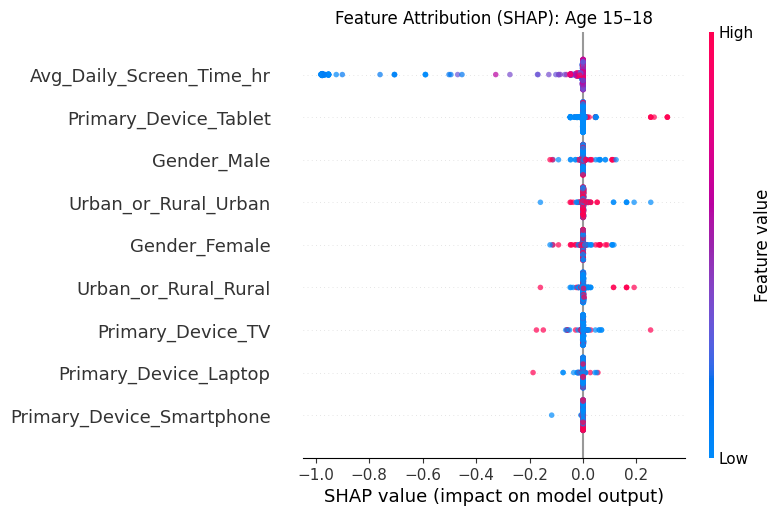


 KEY RESULTS: Age 15–18
  Optimized Screening Threshold: 4.70 hrs/day
  Statistical Independence (p-value): 2.96e-22
  Effect Size (Cramer's V): 0.164


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import warnings

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, confusion_matrix
from scipy.stats import chi2_contingency
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. DATA PREPARATION
# ---------------------------------------------------------
df = pd.read_csv("Screen_time.csv")
df["Reported_Health_Risk"] = df["Health_Impacts"].notna().astype(int)

# Check class distribution
print("Class Distribution:\n", df["Reported_Health_Risk"].value_counts(normalize=True))

age_groups = {
    "Age ≤ 14": df[df["Age"] <= 14].copy(),
    "Age 15–18": df[df["Age"] > 14].copy()
}

def calculate_cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

# ---------------------------------------------------------
# 2. ANALYSIS PIPELINE
# ---------------------------------------------------------
param_grids = {
    "KNN": {'model__n_neighbors': [3, 5, 7, 9, 11]},
    "Logistic Regression": {
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l2']
    },
    "Random Forest": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5, 7],
        'model__class_weight': ['balanced', None] # Dynamically handles imbalance
    },
    "SVM": {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
   }
}

for group_name, data in age_groups.items():
    print(f"\n{'='*95}\n RESEARCH ANALYSIS (PIPELINE BUILD): {group_name}\n{'='*95}")

    X = data[["Avg_Daily_Screen_Time_hr", "Gender", "Primary_Device", "Urban_or_Rural"]]
    X_encoded = pd.get_dummies(X, drop_first=False)
    y = data["Reported_Health_Risk"]

    # STEP 1: Strict 80/20 Split (Hold-out test set for final reporting) [cite: 196-197]
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    metrics_list = []

    model_candidates = {
        "KNN": KNeighborsClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Naive Bayes": GaussianNB(),
        "SVM": SVC(probability=True)
    }

    # Pipeline-based Grid Search
    for name, model in model_candidates.items():
        # Pipeline ensures scaling ONLY happens on training folds
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        if name in param_grids:
            grid_search = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='roc_auc')
            grid_search.fit(X_train, y_train)
            current_best_pipe = grid_search.best_estimator_
            print(f"Optimal Params for {name}: {grid_search.best_params_}")
        else:
            current_best_pipe = pipe.fit(X_train, y_train)

        # Cross-validation
        cv_ops = cross_validate(current_best_pipe, X_train, y_train, cv=cv,
                                scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall'])

        metrics_list.append({
            "Model": name,
            "Mean Accuracy": round(cv_ops['test_accuracy'].mean(), 4),
            "Mean AUC-ROC": round(cv_ops['test_roc_auc'].mean(), 4),
            "Std Dev (ROC_AUC)": round(cv_ops['test_roc_auc'].std(), 4),
            "Mean F1-Score": round(cv_ops['test_f1'].mean(), 4),
            "Mean Recall": round(cv_ops['test_recall'].mean(), 4),
            "pipeline_obj": current_best_pipe
        })

    print("\n Optimization Results :")
    print(pd.DataFrame(metrics_list).drop(columns=['pipeline_obj']).to_string(index=False))

    # Final Model Selection & Test Set Evaluation
    best_entry = max(metrics_list, key=lambda x: x['Mean AUC-ROC'])
    best_model_name = best_entry['Model']
    final_pipeline = best_entry['pipeline_obj']

    print(f"\n Final Evaluation: {best_model_name}")

    y_prob = final_pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    test_auc = auc(fpr, tpr)

    # --- ROC & Confusion Matrix Plots ---
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_tpr, best_fpr = tpr[best_idx], fpr[best_idx]

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (Test AUC = {test_auc:.3f})')
    plt.scatter(best_fpr, best_tpr, color='red', s=100, label=f"Youden's J (Sens:{best_tpr:.2f}, Spec:{1-best_fpr:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'Final ROC: {best_model_name} ({group_name})')
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f'Test Set Confusion Matrix')
    plt.show()

    # --- Optimized SHAP Interpretation ---
    print(f"Generating SHAP Interpretations...")
    # If best model is Random Forest, use the faster TreeExplainer
    if best_model_name == "Random Forest":
        explainer = shap.TreeExplainer(final_pipeline.named_steps['model'])
        X_test_scaled = final_pipeline.named_steps['scaler'].transform(X_test)
        shap_vals = explainer.shap_values(X_test_scaled)
        # RF SHAP returns a list for classes; we take the positive class
        if isinstance(shap_vals, list): shap_vals = shap_vals[1]
    else:
        # KernelExplainer for non-tree models
        background = shap.kmeans(final_pipeline.named_steps['scaler'].transform(X_train), 10)
        explainer = shap.KernelExplainer(final_pipeline.named_steps['model'].predict, background)
        shap_vals = explainer.shap_values(final_pipeline.named_steps['scaler'].transform(X_test.iloc[:500, :]))

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test.iloc[:len(shap_vals), :], show=False, alpha=0.7)
    plt.title(f"Feature Attribution (SHAP): {group_name}")
    plt.show()

    # --- FINAL STATISTICAL FINDINGS ---
    # Thresholding logic based on full group data
    final_pipeline.fit(X_train, y_train)

    all_probs = final_pipeline.predict_proba(X_train)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_train, all_probs)
    opt_thresh = thresholds[np.argmax(tpr - fpr)]

    screen_limit = X_train.loc[all_probs >= opt_thresh, "Avg_Daily_Screen_Time_hr"].median()
    data["Exceeds_Threshold"] = (data["Avg_Daily_Screen_Time_hr"] > screen_limit).astype(int)

    contingency = pd.crosstab(data["Exceeds_Threshold"], data["Reported_Health_Risk"])
    _, p_val, _, _ = chi2_contingency(contingency)

    print(f"\n KEY RESULTS: {group_name}")
    print(f"  Optimized Screening Threshold: {screen_limit:.2f} hrs/day")
    print(f"  Statistical Independence (p-value): {p_val:.2e}")
    print(f"  Effect Size (Cramer's V): {calculate_cramers_v(contingency):.3f}")